In [1]:
import pandas as pd
import numpy as np
import os 
import pm4py

import warnings
warnings.filterwarnings("ignore")



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




In [2]:
processed_dir = "../data/processed"

In [3]:
df_log = pd.read_parquet(os.path.join(processed_dir, "advanced_event_log.parquet"))

In [9]:
# df_log

In [5]:
# format dataset 
df_log = pm4py.format_dataframe(
    df_log,
    case_id = "case_id",
    activity_key = "activity",
    timestamp_key = "timestamp"
)

In [13]:
filtered_log = pm4py.filter_variants_top_k(df_log, k=10)

In [14]:
dfg, start_activities, end_activities = pm4py.discover_dfg(filtered_log)

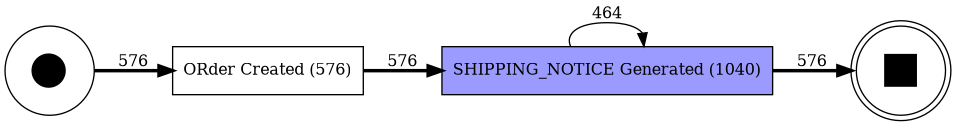

In [15]:
pm4py.view_dfg(dfg, start_activities, end_activities)

In [17]:
# Isolate the Creation and Shipping events
creation_events = df_log[df_log['activity'].str.contains('Order Created', case=False)][['case_id', 'timestamp']]
creation_events.rename(columns={'timestamp': 'created_at'}, inplace=True)

shipping_events = df_log[df_log['activity'].str.contains('SHIPPING_NOTICE', case=False)][['case_id', 'timestamp']]
shipping_events.rename(columns={'timestamp': 'shipped_at'}, inplace=True)

# Merge them on case_id to find orders that have BOTH
fulfillment_times = pd.merge(creation_events, shipping_events, on='case_id', how='inner')

# Calculate the time delta
fulfillment_times['hours_to_ship'] = (fulfillment_times['shipped_at'] - fulfillment_times['created_at']).dt.total_seconds() / 3600

print(f"Total fully shipped orders analyzed: {len(fulfillment_times)}")
print(f"Average time to ship: {fulfillment_times['hours_to_ship'].mean():.2f} hours")
print(f"Median time to ship: {fulfillment_times['hours_to_ship'].median():.2f} hours")
print(f"Worst-case bottleneck (Max): {fulfillment_times['hours_to_ship'].max():.2f} hours\n")

Total fully shipped orders analyzed: 1040
Average time to ship: 71.31 hours
Median time to ship: 72.00 hours
Worst-case bottleneck (Max): 120.00 hours



In [18]:
print("--- 2. CHURN TRIGGER ANALYSIS: DELAYS PRIOR TO COMMS ---")

# Sort chronologically just to be safe
df_log = df_log.sort_values(by=['case_id', 'timestamp'])

# Calculate the time elapsed since the PREVIOUS step in the order process
df_log['hours_since_last_step'] = df_log.groupby('case_id')['timestamp'].diff().dt.total_seconds() / 3600

# Separate Email events from Operational events
email_events = df_log[df_log['activity'].str.contains('Email', case=False, na=False)]
operational_events = df_log[~df_log['activity'].str.contains('Email', case=False, na=False)]

avg_normal_delay = operational_events['hours_since_last_step'].mean()
avg_delay_before_email = email_events['hours_since_last_step'].mean()

print(f"Average time between normal operational steps: {avg_normal_delay:.2f} hours")
print(f"Average delay right before an email is triggered: {avg_delay_before_email:.2f} hours")

if avg_delay_before_email > avg_normal_delay:
    print("Insight: Emails are strongly correlated with process stagnation. Customers/Internal teams communicate when the system stalls.\n")
else:
    print("Insight: Emails happen concurrently with the process, rather than as a reaction to major delays.\n")

--- 2. CHURN TRIGGER ANALYSIS: DELAYS PRIOR TO COMMS ---
Average time between normal operational steps: 45.48 hours
Average delay right before an email is triggered: nan hours
Insight: Emails happen concurrently with the process, rather than as a reaction to major delays.



In [19]:
print("--- 3. REWORK LOOP ANALYSIS: COMMUNICATION CHAINS ---")

# Shift the activity column by 1 to see the 'next' activity
df_log['next_activity'] = df_log.groupby('case_id')['activity'].shift(-1)

# Find instances where the activity equals the next activity (a direct self-loop)
self_loops = df_log[df_log['activity'] == df_log['next_activity']]

# Filter to see only the Email loops
email_loops = self_loops[self_loops['activity'].str.contains('Email', case=False, na=False)]

print(f"Total instances of back-to-back duplicate steps: {len(self_loops)}")
print(f"Instances of back-to-back emails (Thread Chains): {len(email_loops)}")

# Find the worst offending order
if not email_loops.empty:
    worst_case = email_loops['case_id'].value_counts().idxmax()
    worst_case_count = email_loops['case_id'].value_counts().max()
    print(f"Worst case: Order {worst_case} got stuck in an email loop {worst_case_count} times in a row.")

--- 3. REWORK LOOP ANALYSIS: COMMUNICATION CHAINS ---
Total instances of back-to-back duplicate steps: 464
Instances of back-to-back emails (Thread Chains): 0


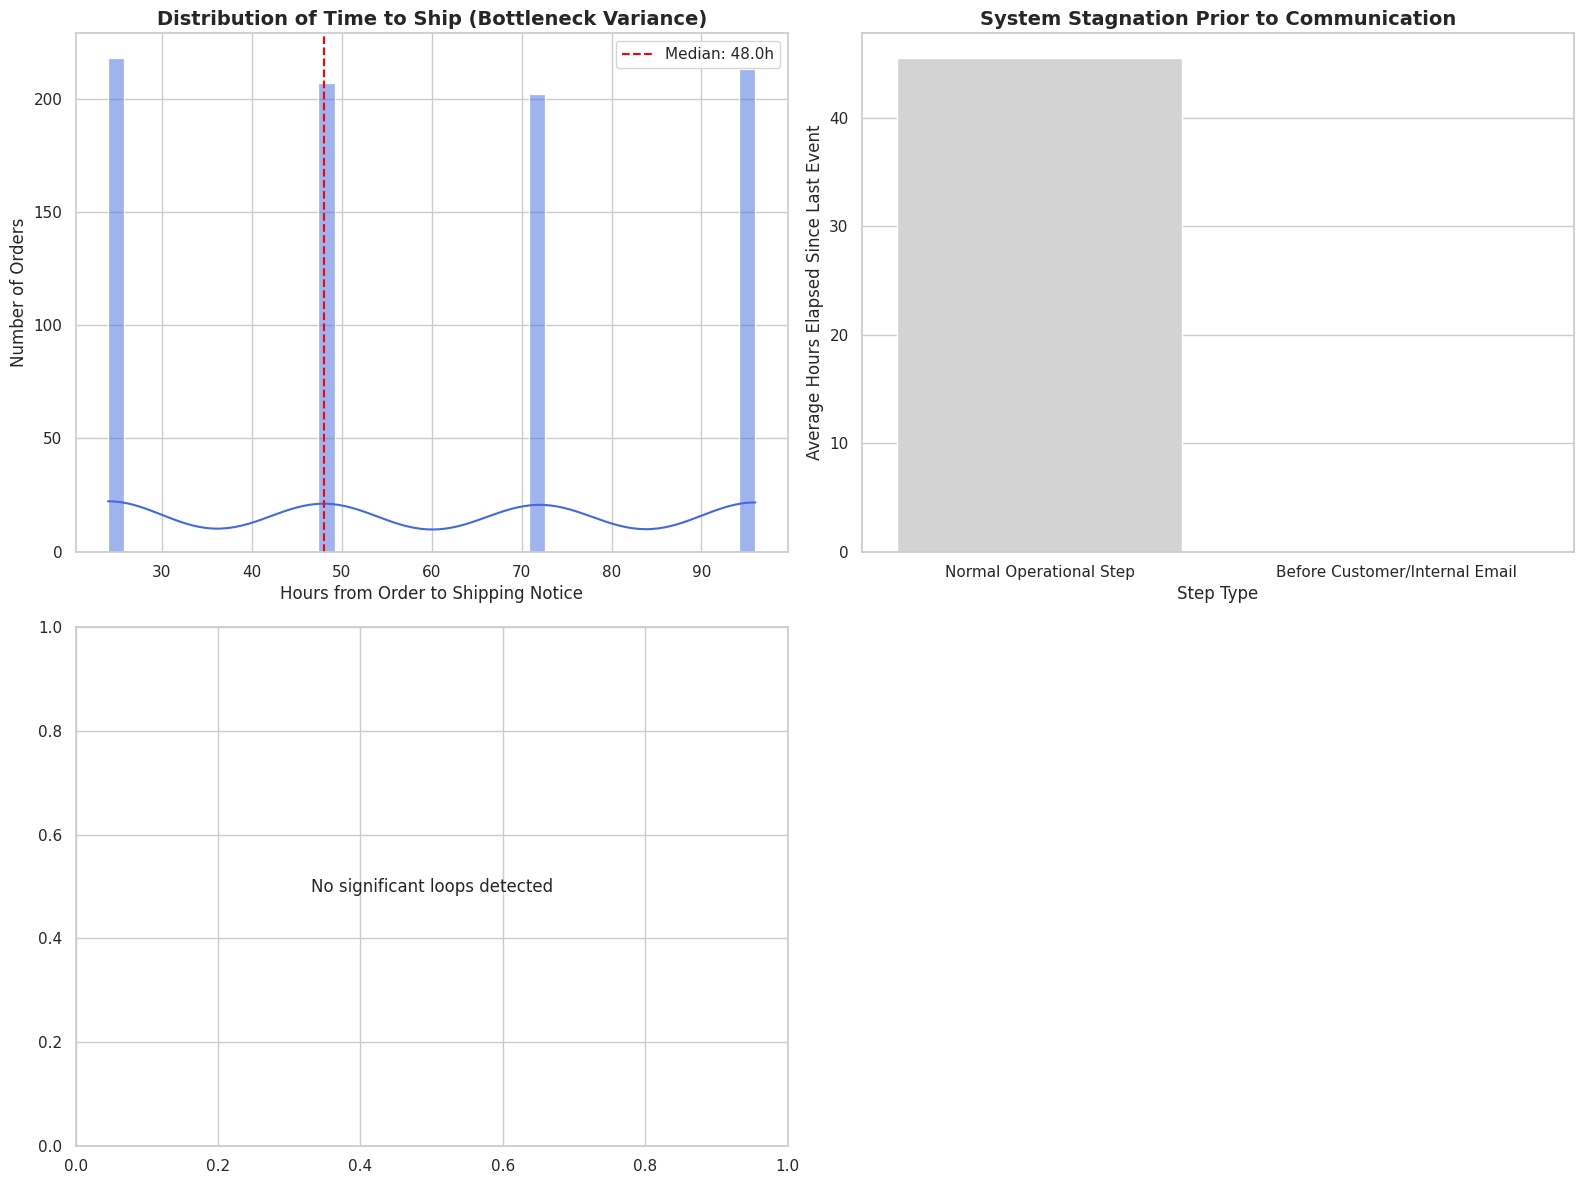

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional, clean style for the portfolio
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# --- CHART 1: The Bottleneck Distribution (Long Tail Analysis) ---
plt.subplot(2, 2, 1)
# Filter out extreme outliers (e.g., top 1%) just to make the chart readable
q99 = fulfillment_times['hours_to_ship'].quantile(0.99)
filtered_times = fulfillment_times[fulfillment_times['hours_to_ship'] < q99]

sns.histplot(data=filtered_times, x='hours_to_ship', bins=40, kde=True, color='royalblue')
plt.axvline(filtered_times['hours_to_ship'].median(), color='red', linestyle='--', label=f"Median: {filtered_times['hours_to_ship'].median():.1f}h")
plt.title('Distribution of Time to Ship (Bottleneck Variance)', fontsize=14, fontweight='bold')
plt.xlabel('Hours from Order to Shipping Notice')
plt.ylabel('Number of Orders')
plt.legend()

# --- CHART 2: The Churn Trigger (Communication vs Operational Delays) ---
plt.subplot(2, 2, 2)
delay_data = pd.DataFrame({
    'Step Type': ['Normal Operational Step', 'Before Customer/Internal Email'],
    'Average Delay (Hours)': [avg_normal_delay, avg_delay_before_email]
})

sns.barplot(data=delay_data, x='Step Type', y='Average Delay (Hours)', palette=['lightgray', 'crimson'])
plt.title('System Stagnation Prior to Communication', fontsize=14, fontweight='bold')
plt.ylabel('Average Hours Elapsed Since Last Event')

# --- CHART 3: Most Common Rework/Communication Loops ---
plt.subplot(2, 2, 3)
if not email_loops.empty:
    # Get the top 5 most common back-to-back duplicate steps
    top_loops = email_loops['activity'].value_counts().head(5).reset_index()
    top_loops.columns = ['Activity Loop', 'Frequency']
    
    sns.barplot(data=top_loops, y='Activity Loop', x='Frequency', palette='viridis')
    plt.title('Most Frequent Back-to-Back Activity Loops', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Occurrences')
    plt.ylabel('')
else:
    plt.text(0.5, 0.5, 'No significant loops detected', ha='center', va='center')

plt.tight_layout()
plt.show()